In [30]:
import numpy as np
import cv2 as cv2
import glob
from matplotlib import pyplot as plt
import sys

sys.path.append('../..')
from utils import *

# Question 9

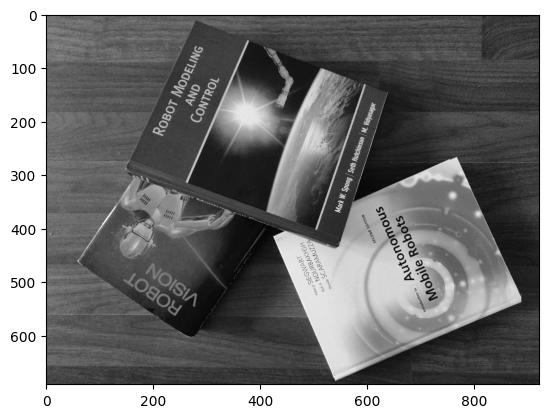

In [ ]:
img = cv2.imread("data/books.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap="grey")

In [6]:
edges = cv2.Canny(gray, 100, 200)
lines = cv2.HoughLines(edges, 1, 0.0017, 200)
lines.shape

(32, 1, 2)

# Question 10

In [14]:
corners = cv2.cornerHarris(gray, 2, 3, 0.04)

(corners > 0.01).sum()

np.int64(188)

# Question 18

In [28]:
left = cv2.imread("data/left.png", cv2.IMREAD_GRAYSCALE)
right = cv2.imread("data/right.png", cv2.IMREAD_GRAYSCALE)

sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute(left, None)
kp2, des2 = sift.detectAndCompute(right, None)

matcher = cv2.BFMatcher()
matches = matcher.match(des1, des2)

# Sort them in the order of their distance (i.e. best matches first).
matches = sorted(matches, key = lambda x:x.distance)

nb_matches = 2000

pts1 = []
pts2 = []

for m in matches[:nb_matches]:
    pts1.append(kp1[m.queryIdx].pt)
    pts2.append(kp2[m.trainIdx].pt)

pts1 = np.int32(pts1)
pts2 = np.int32(pts2)
    
F, mask = cv2.findFundamentalMat(pts1, pts2, cv2.FM_RANSAC)

# We select only inlier points
pts1 = pts1[mask.ravel() == 1]
pts2 = pts2[mask.ravel() == 1]

# Find epilines corresponding to points in right image (second image)
lines1 = cv2.computeCorrespondEpilines(pts2.reshape(-1, 1, 2), 2 ,F)
lines1 = lines1.reshape(-1, 3)

# Find epilines corresponding to points in left image (first image) and
# drawing its lines on right image
lines2 = cv2.computeCorrespondEpilines(pts1.reshape(-1, 1, 2), 1, F)
lines2 = lines2.reshape(-1, 3)

print(np.average(lines1, axis=0))
print(np.average(lines2, axis=0))

[-6.69333264e-02  9.97691572e-01 -1.26727486e+02]
[ 7.0291542e-02 -9.9747336e-01  1.2541019e+02]


# Question 19

# Question 23

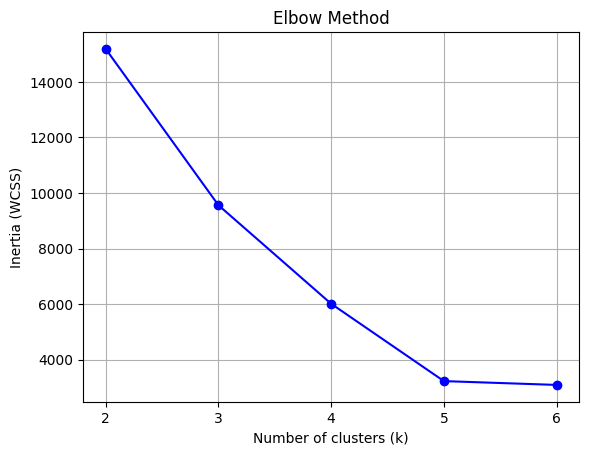

In [32]:
data = np.loadtxt('data/clusters.txt')
plot_elbow_graph(data, min_clusters=2, max_clusters=6)

# Question 32

In [ ]:
def getK():
    return np.array([[7.188560e+02, 0.000000e+00, 6.071928e+02],
                     [0, 7.188560e+02, 1.852157e+02],
                     [0, 0, 1]])

def getTruePose():
    file = '00.txt'
    return np.genfromtxt(file, delimiter=' ', dtype=None)

def extract_keypoints_sift(img1, img2, K, baseline):
    """
    Use SIFT to detect keypoints and compute descriptors in both images,
    and find matches between them using knnMatch with k=2
    """
    sift = cv2.SIFT_create()
    kp1, desc1 = sift.detectAndCompute(img1, None)
    kp2, desc2 = sift.detectAndCompute(img2, None)
    
    # Use BFMatcher with knnMatch (k=2 for ratio test)
    bf = cv2.BFMatcher()
    matches = bf.knnMatch(desc1, desc2, k=2)

    """
    Get the best keypoints by applying the Lowes ratio test
    """
    match_points1 = []
    match_points2 = []
    for m, n in matches:
        # Lowe's ratio test: keep match if distance ratio < 0.75
        if m.distance < 0.75 * n.distance:
            match_points1.append(kp1[m.queryIdx].pt)
            match_points2.append(kp2[m.trainIdx].pt)
    
    # Transform best keypoints to nparray
    p1 = np.array(match_points1).astype('float32')
    p2 = np.array(match_points2).astype('float32')

    ##### ############# ##########
    ##### Do Triangulation #######
    ##### ########################
    # project the feature points to 3D with triangulation
    # projection matrix for Left and Right Image
    M_left = K.dot(np.hstack((np.eye(3), np.zeros((3, 1)))))
    M_rght = K.dot(np.hstack((np.eye(3), np.array([[-baseline, 0, 0]]).T)))

    p1_flip = np.vstack((p1.T, np.ones((1, p1.shape[0]))))
    p2_flip = np.vstack((p2.T, np.ones((1, p2.shape[0]))))

    P = cv2.triangulatePoints(M_left, M_rght, p1_flip[:2], p2_flip[:2])

    # Normalize homogeneous coordinates (P->Nx4  [N,4] is the normalizer/scale)
    P = P / P[3]
    land_points = P[:3]

    return land_points.T, p1

def featureTracking(prev_img, next_img, prev_points, world_points):
    """
    Use OpenCV to find the prev_points from the prev_img in the next_img
    Remember to remove points that could not be found from prev_points, next_points, and world_points
    hint: status == 1
    """
    params = dict(winSize=(21, 21),
                 maxLevel=3,
                 criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 30, 0.01))
    
    # Use Lucas-Kanade optical flow to track points
    next_points, status, _ = cv2.calcOpticalFlowPyrLK(prev_img, next_img, prev_points, None, **params)
    
    # Filter out points that could not be tracked (status == 1 means successfully tracked)
    status = status.flatten() == 1
    world_points = world_points[status]
    prev_points = prev_points[status]
    next_points = next_points[status]

    return world_points, prev_points, next_points

def playImageSequence(l_img_paths, r_img_paths, K):
    baseline = 0.54
    left_img = cv2.imread(l_img_paths[0], 0)
    right_img = cv2.imread(r_img_paths[0], 0)

    ##### ################################# #######
    ##### Get 3D points Using Triangulation #######
    ##### #########################################
    """
    Implement step 1.2 and 1.3
    Store the features in 'reference_2D' and the 3D points (landmarks) in 'landmark_3D'
    hint: use 'extract_keypoints_sift' above
    """
    # Step 1.2 and 1.3: Extract keypoints and triangulate to get initial 3D landmarks
    landmark_3D, reference_2D = extract_keypoints_sift(left_img, right_img, K, baseline)

    # reference
    reference_img = left_img

    # Groundtruth for plot
    traj = np.zeros((600, 600, 3), dtype=np.uint8)
    maxError = 0

    for i in range(1, 101):
        print('image: ', i)
        curImage = cv2.imread(l_img_paths[i], 0)
        curImage_R = cv2.imread(r_img_paths[i], 0)

        ##### ############################################################# #######
        ##### Calculate 2D and 3D feature correspndances in t=T-1, and t=T  #######
        ##### #####################################################################
        """
        Implement step 2.2)
        Remember this is a part of a loop, so the initial features are already
        provided in step 1)-1.3) outside the loop in 'reference_2D' and 'landmark_3D'
        """
        # Step 2.2: Track features from previous frame to current frame
        landmark_3D, reference_2D, tracked_2Dpoints = featureTracking(reference_img, 
                                                                       curImage, 
                                                                       reference_2D,
                                                                       landmark_3D)

        ##### ####################################### #######
        ##### Calculate relative pose using PNPRansac #######
        ##### ###############################################
        """
        Implement step 2.3)
        """
        # Step 2.3: PnP with RANSAC to estimate camera pose
        _, rvec, tvec, inliers = cv2.solvePnPRansac(landmark_3D, tracked_2Dpoints, K, None)

        ##### ####################################################### #######
        ##### Get Pose and Tranformation Matrix in world coordionates #######
        ##### ###############################################################
        rot, _ = cv2.Rodrigues(rvec)
        tvec = -rot.T.dot(tvec)  # coordinate transformation, from camera to world. What is the XYZ of the camera wrt World
        inv_transform = np.hstack((rot.T, tvec))  # inverse transform. A tranform projecting points from the camera frame to the world frame

        ##### ################################# #######
        ##### Get 3D points Using Triangulation #######
        ##### #########################################
        # re-obtain the 3D points. 
        # hint: use 'extract_keypoints_sift' again
        """
        Implement step 2.4)
        """
        # Step 2.4: Re-triangulate to get new 3D points for the next iteration
        landmark_3D_new, reference_2D_new = extract_keypoints_sift(curImage, curImage_R, K, baseline)
        
        #Project the points from camera to world coordinates
        reference_2D = reference_2D_new.astype('float32')
        landmark_3D = inv_transform.dot(np.vstack((landmark_3D_new.T, np.ones((1, landmark_3D_new.shape[0])))))
        landmark_3D = landmark_3D.T

        ##### ####################### #######
        ##### Done, Next image please #######
        ##### ###############################
        reference_img = curImage

        ##### ################################## #######
        ##### START OF Print and visualize stuff #######
        ##### ##########################################
        # draw images
        draw_x, draw_y = int(tvec[0]) + 300, 600-(int(tvec[2]) + 100)
        

        print(tvec[0],tvec[1],tvec[2], rvec[0], rvec[1], rvec[2])
        
        text = "Coordinates: x ={0:02f}m y = {1:02f}m z = {2:02f}m".format(float(tvec[0]), float(tvec[1]),
                                                                           float(tvec[2]))
        cv2.circle(traj, (draw_x, draw_y), 1, (0, 0, 255), 2)
        cv2.rectangle(traj, (10, 30), (550, 50), (0, 0, 0), cv2.FILLED)
        cv2.putText(traj, text, (10, 50), cv2.FONT_HERSHEY_PLAIN, 1, (255, 255, 255), 1, 8)

        h1, w1 = traj.shape[:2]
        h2, w2 = curImage.shape[:2]
        vis = np.zeros((max(h1, h2), w1 + w2, 3), np.uint8)
        vis[:h1, :w1, :3] = traj
        vis[:h2, w1:w1 + w2, :3] = np.dstack((np.dstack((curImage,curImage)),curImage))

        cv2.imshow("Trajectory", vis)
        k = cv2.waitKey(1) & 0xFF
        if k == 27: break

    cv2.destroyAllWindows()
    cv2.waitKey(1)
    cv2.destroyAllWindows()
    print('Maximum Error: ', maxError)
    ##### ################################ #######
    ##### END OF Print and visualize stuff #######
    ##### ########################################

In [ ]:
left_img_paths = sorted(glob.glob('data/images/left/*.png'))
right_img_paths = sorted(glob.glob('data/images/right/*.png'))

K = getK()

playImageSequence(left_img_paths, right_img_paths, K)

image:  1
[-0.01390306] [-0.01556274] [0.62680282] [0.00309446] [0.00038947] [0.00184009]


/var/folders/7y/2z6fy9wj2gvdg90fmrn33q4h0000gn/T/ipykernel_83957/3958003393.py:165: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  draw_x, draw_y = int(tvec[0]) + 300, 600-(int(tvec[2]) + 100)
/var/folders/7y/2z6fy9wj2gvdg90fmrn33q4h0000gn/T/ipykernel_83957/3958003393.py:170: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  text = "Coordinates: x ={0:02f}m y = {1:02f}m z = {2:02f}m".format(float(tvec[0]), float(tvec[1]),
/var/folders/7y/2z6fy9wj2gvdg90fmrn33q4h0000gn/T/ipykernel_83957/3958003393.py:171: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single ele

image:  2
[-0.02088464] [-0.02956055] [1.21965435] [0.00596186] [0.00275891] [7.83198345e-05]
image:  3
[-0.02137137] [-0.04459327] [1.78860439] [0.00567033] [0.00760286] [-0.00582741]
image:  4
[-0.03045433] [-0.06183239] [2.33612169] [0.00387879] [0.01552567] [-0.00934377]
image:  5
[-0.04965584] [-0.07763254] [2.86745656] [0.00036013] [0.02621078] [-0.01142969]
image:  6
[-0.08673447] [-0.08959087] [3.38858592] [-0.00309194] [0.04013612] [-0.01164066]
image:  7
[-0.13340695] [-0.10267759] [3.89061903] [-0.00517588] [0.05883637] [-0.01168207]
image:  8
[-0.18753318] [-0.11488979] [4.3946884] [-0.00379916] [0.08070843] [-0.01492492]
image:  9
[-0.26076134] [-0.13035595] [4.89476804] [-0.00065131] [0.10526656] [-0.0120436]
image:  10
[-0.34317852] [-0.14800151] [5.37690307] [0.0026982] [0.13345897] [-0.01146336]
image:  11
[-0.43698099] [-0.15785777] [5.85387282] [0.00313623] [0.16616326] [-0.01291645]
image:  12
[-0.55308453] [-0.17034952] [6.3063023] [0.00040682] [0.20285583] [-0.009

IndexError: list index out of range

: 